# Unidad 2: Aprendizaje Automático
## Métricas de Evaluación
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/17_Metricas.ipynb)


## 🎯 ¿Qué vamos a aprender?

Entrenar un modelo es solo la mitad del trabajo. La otra mitad es **saber cómo medirlo correctamente**. En este notebook vamos a fondo en las métricas de evaluación para clasificación binaria.

Al finalizar, vas a poder:
- ✅ Entender qué mide cada métrica: **Accuracy, Precision, Recall y F1**
- ✅ Interpretar la **Matriz de Confusión** y sus cuatro cuadrantes (TP, FP, TN, FN)
- ✅ Calcular métricas desde scikit-learn sobre un dataset real
- ✅ Visualizar e interpretar la **Matriz de Confusión** gráficamente
- ✅ Elegir la métrica correcta según el contexto del problema

---

## 🧠 Marco Teórico

### 🗂️ La Matriz de Confusión

Toda evaluación de un clasificador binario parte de la **Matriz de Confusión**, que organiza los resultados en 4 categorías:

```
                    PREDICHO
                 Positivo  Negativo
REAL  Positivo │   TP    │   FN   │
      Negativo │   FP    │   TN   │
```

| Sigla | Nombre | Significado |
|-------|--------|-------------|
| **TP** | True Positive  | Predijo positivo ✅ y era positivo |
| **TN** | True Negative  | Predijo negativo ✅ y era negativo |
| **FP** | False Positive | Predijo positivo ❌ pero era negativo (Error Tipo I) |
| **FN** | False Negative | Predijo negativo ❌ pero era positivo (Error Tipo II) |

### 📐 Las Métricas y sus Fórmulas

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

### 🤔 ¿Por qué Accuracy sola no alcanza?

Imaginá un dataset con **95% de clase negativa** y **5% de clase positiva**. Un modelo que prediga *siempre negativo* tendrá 95% de Accuracy... ¡sin aprender nada útil! En estos casos, Precision, Recall y F1 son mucho más informativas.

### 🚢 El Dataset: Titanic

Usaremos el clásico dataset del **Titanic** para predecir si un pasajero sobrevivió (1) o no (0).

| Columna | Descripción |
|---------|-------------|
| `Pclass` | Clase del pasajero (1=Primera, 2=Segunda, 3=Tercera) |
| `Sex` | Sexo (`male` / `female`) |
| `Age` | Edad |
| `Siblings/Spouses` | N° de hermanos/cónyuge a bordo |
| `Parents/Children` | N° de padres/hijos a bordo |
| `Fare` | Tarifa pagada |
| `Survived` | **Variable objetivo**: 1 = Sobrevivió, 0 = No sobrevivió |

> 📌 **Referencias:**
> - Scikit-learn: [sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics)
> - Fawcett, T. (2006). [An introduction to ROC analysis](https://doi.org/10.1016/j.patrec.2005.10.010). *Pattern Recognition Letters*, 27(8), 861–874.
> - Powers, D. M. W. (2011). [Evaluation: From Precision, Recall and F-Factor to ROC, Informedness, Markedness & Correlation](https://arxiv.org/abs/2010.16061). *Journal of Machine Learning Technologies*.

---

## 📦 Paso 1: Importar las Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 📊 Métricas individuales
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 🔲 Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print('✅ Librerías importadas correctamente!')

✅ Librerías importadas correctamente!


## 📂 Paso 2: Cargar y Explorar el Dataset

In [2]:
# 📥 Cargar el dataset Titanic
df = pd.read_csv('https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/data/ml/titanic.csv')

# 🔄 Variable binaria: 1 si es hombre, 0 si es mujer
df['male'] = df['Sex'] == 'male'

print(f'📐 Dimensiones: {df.shape[0]} pasajeros × {df.shape[1]} columnas')
print(f'\n📊 Distribución de supervivencia:')
print(df['Survived'].value_counts().rename({0: 'No sobrevivió (0)', 1: 'Sobrevivió (1)'}))
df.head()

📐 Dimensiones: 887 pasajeros × 8 columnas

📊 Distribución de supervivencia:
Survived
No sobrevivió (0)    545
Sobrevivió (1)       342
Name: count, dtype: int64


,Survived,Pclass,Sex,Age,Siblings/Spouses,Parents/Children,Fare,male
0,0,3,male,22.0,1,0,7.2500,True
1,1,1,female,38.0,1,0,71.2833,False
2,1,3,female,26.0,0,0,7.9250,False
3,1,1,female,35.0,1,0,53.1000,False
4,0,3,male,35.0,0,0,8.0500,True


## 🎯 Paso 3: Preparar Features y Dividir los Datos

In [4]:
# 🎯 Selección de features
X = df[['Pclass', 'male', 'Age', 'Siblings/Spouses', 'Parents/Children', 'Fare']].values
y = df['Survived'].values

# ✂️ División train (75%) / test (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print(f'🏋️  Entrenamiento: {X_train.shape[0]} pasajeros')
print(f'🧪  Prueba:        {X_test.shape[0]} pasajeros')
print(f'\n📊 Distribución en test:')
import numpy as np
vals, cnts = np.unique(y_test, return_counts=True)
for v, c in zip(vals, cnts):
    print(f'  Clase {v}: {c} ({c/len(y_test)*100:.1f}%)')

🏋️  Entrenamiento: 665 pasajeros
🧪  Prueba:        222 pasajeros

📊 Distribución en test:
  Clase 0: 140 (63.1%)
  Clase 1: 82 (36.9%)


## 🤖 Paso 4: Entrenar el Modelo

Usamos **Regresión Logística**: un modelo lineal que predice la probabilidad de pertenecer a cada clase.

In [5]:
# 🤖 Entrenar Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 🔮 Predicciones sobre el test set
y_pred = model.predict(X_test)

print('✅ Modelo entrenado y predicciones generadas!')
print(f'\n📋 Primeras 10 predicciones vs valores reales:')
comparacion = pd.DataFrame({'Real': y_test[:10], 'Predicho': y_pred[:10]})
comparacion['Correcto'] = comparacion['Real'] == comparacion['Predicho']
comparacion['Correcto'] = comparacion['Correcto'].map({True: '✅', False: '❌'})
print(comparacion.to_string(index=False))

✅ Modelo entrenado y predicciones generadas!

📋 Primeras 10 predicciones vs valores reales:
 Real  Predicho Correcto
    1         0        ❌
    0         0        ✅
    0         0        ✅
    1         0        ❌
    0         0        ✅
    1         1        ✅
    0         0        ✅
    0         0        ✅
    1         1        ✅
    1         1        ✅


## 📊 Paso 5: Calcular y Analizar las Métricas

Calculamos todas las métricas de evaluación para el conjunto de **prueba**.

> ⚠️ **Importante:** Siempre evaluar sobre el conjunto de *prueba* (datos que el modelo nunca vio), no sobre el de entrenamiento.

In [7]:
# 📊 Calcular métricas
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 45)
print('        📊 MÉTRICAS DE EVALUACIÓN')
print('=' * 45)
print(f'  model.score:  {model.score(X_test, y_test):.5f}  (≡ accuracy)')
print(f'  Accuracy:     {acc:.5f}')
print(f'  Precision:    {prec:.5f}')
print(f'  Recall:       {rec:.5f}')
print(f'  F1 Score:     {f1:.5f}')
print('=' * 45)

print(f'\n🔢 Distribución real en test ({len(y_test)} pasajeros):')
print(f'  Verdaderos Positivos (sobrevivieron): {(y_test == 1).sum()}')
print(f'  Verdaderos Negativos (no sobreviv.):  {(y_test == 0).sum()}')
print(f'\n🔮 Predicciones generadas:')
print(f'  Predichos Positivos: {(y_pred == 1).sum()}')
print(f'  Predichos Negativos: {(y_pred == 0).sum()}')

        📊 MÉTRICAS DE EVALUACIÓN
  model.score:  0.76577  (≡ accuracy)
  Accuracy:     0.76577
  Precision:    0.72727
  Recall:       0.58537
  F1 Score:     0.64865

🔢 Distribución real en test (222 pasajeros):
  Verdaderos Positivos (sobrevivieron): 82
  Verdaderos Negativos (no sobreviv.):  140

🔮 Predicciones generadas:
  Predichos Positivos: 66
  Predichos Negativos: 156


## 🔲 Paso 6: Matriz de Confusión

La **Matriz de Confusión** muestra en detalle dónde acierta y dónde falla el modelo.

In [9]:
# 🔲 Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

tn, fp, fn, tp = cm.ravel()
print('🔲 Matriz de Confusión (valores):')
print(cm)
print()
print(f'  ✅ Verdaderos Negativos (TN): {tn}  → predijo No, era No')
print(f'  ❌ Falsos Positivos    (FP): {fp}  → predijo Sí, era No   [Error T. I]')
print(f'  ❌ Falsos Negativos    (FN): {fn}  → predijo No, era Sí   [Error T. II]')
print(f'  ✅ Verdaderos Positivos (TP): {tp}  → predijo Sí, era Sí')

🔲 Matriz de Confusión (valores):
[[122  18]
 [ 34  48]]

  ✅ Verdaderos Negativos (TN): 122  → predijo No, era No
  ❌ Falsos Positivos    (FP): 18  → predijo Sí, era No   [Error T. I]
  ❌ Falsos Negativos    (FN): 34  → predijo No, era Sí   [Error T. II]
  ✅ Verdaderos Positivos (TP): 48  → predijo Sí, era Sí


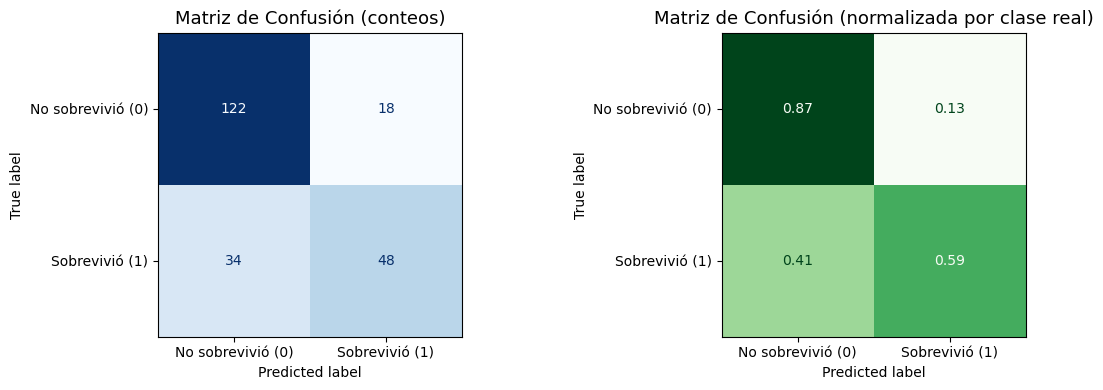

In [10]:
# 📊 Visualización de la Matriz de Confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No sobrevivió (0)', 'Sobrevivió (1)'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión (conteos)', fontsize=13)

# Normalizada
cm_norm = confusion_matrix(y_test, y_pred, labels=model.classes_, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                               display_labels=['No sobrevivió (0)', 'Sobrevivió (1)'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matriz de Confusión (normalizada por clase real)', fontsize=13)

plt.tight_layout()
plt.show()

## 🔍 Paso 7: Verificar las Fórmulas Manualmente

In [11]:
# 🧮 Verificación manual de las fórmulas a partir de la matriz de confusión
acc_manual  = (tp + tn) / (tp + tn + fp + fn)
prec_manual = tp / (tp + fp)
rec_manual  = tp / (tp + fn)
f1_manual   = 2 * prec_manual * rec_manual / (prec_manual + rec_manual)

print('🧮 Verificación manual de fórmulas:')
print(f'  Accuracy  = (TP+TN)/(TP+TN+FP+FN) = ({tp}+{tn})/({tp}+{tn}+{fp}+{fn}) = {acc_manual:.5f}')
print(f'  Precision = TP/(TP+FP)             = {tp}/({tp}+{fp}) = {prec_manual:.5f}')
print(f'  Recall    = TP/(TP+FN)             = {tp}/({tp}+{fn}) = {rec_manual:.5f}')
print(f'  F1        = 2·P·R/(P+R)            = {f1_manual:.5f}')

print('\n✅ Coinciden con sklearn:', 
      all(abs(x - y) < 1e-10 for x, y in [
          (acc_manual, acc), (prec_manual, prec),
          (rec_manual, rec), (f1_manual, f1)
      ]))

🧮 Verificación manual de fórmulas:
  Accuracy  = (TP+TN)/(TP+TN+FP+FN) = (48+122)/(48+122+18+34) = 0.76577
  Precision = TP/(TP+FP)             = 48/(48+18) = 0.72727
  Recall    = TP/(TP+FN)             = 48/(48+34) = 0.58537
  F1        = 2·P·R/(P+R)            = 0.64865

✅ Coinciden con sklearn: True


## 📈 Paso 8: Visualización Comparativa de Métricas

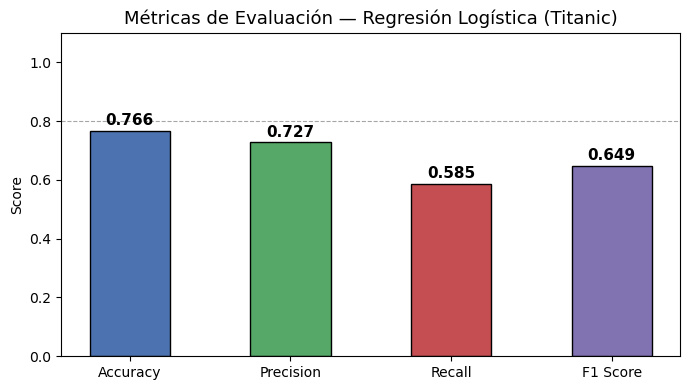

In [12]:
# 📊 Barplot de métricas
metricas = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}
colores  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metricas.keys(), metricas.values(), color=colores, edgecolor='black', width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Métricas de Evaluación — Regresión Logística (Titanic)', fontsize=13)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

for bar, val in zip(bars, metricas.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 🏁 Conclusiones

En este notebook aprendimos:

1. 🔲 La **Matriz de Confusión** es la base de todas las métricas de clasificación binaria.
2. 📐 **Accuracy** mide el porcentaje global de aciertos, pero puede ser engañosa con clases desbalanceadas.
3. 🎯 **Precision** mide la calidad de los positivos predichos (¿cuántos de los que predije positivos lo eran realmente?).
4. 🔍 **Recall** mide la cobertura de los positivos reales (¿cuántos verdaderos positivos encontré?).
5. ⚖️ **F1 Score** balancea Precision y Recall en una sola métrica, ideal cuando ambos son importantes.

### ➡️ Próximo notebook: Sensibilidad, Especificidad y Umbral de Decisión

---

## 📚 Referencias

- Scikit-learn: [sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics)
- Scikit-learn: [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
- Fawcett, T. (2006). [An introduction to ROC analysis](https://doi.org/10.1016/j.patrec.2005.10.010). *Pattern Recognition Letters*, 27(8), 861–874.
- Powers, D. M. W. (2011). [Evaluation: From Precision, Recall and F-Factor to ROC, Informedness, Markedness & Correlation](https://arxiv.org/abs/2010.16061).

---

© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas

Este notebook se distribuye bajo licencia [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).